# Mesa ABM for SIR

## Import packages

In [ ]:
import os
print(os.getcwd())
from scorefilter import EnSF
import numpy as np
import disease_model
import matplotlib.pyplot as plt
#import disease_visualization
#from IPython.display import HTML

In [3]:
def check_paramater(input_para):
    input_para[input_para<0.01] = 0.01
    input_para[input_para>0.99] = 0.99
    return input_para


def sir_balance(S, I, R):
    """
    Fixes negative values in S by transferring them evenly to I and R.
    Assumes S, I, R are integer arrays of the same shape.
    """
    S = S.copy()
    I = I.copy()
    R = R.copy()
    total_before = S + I + R

    # Find where S is negative
    negative_mask = S < 0
    negative_values = -S[negative_mask]  # amount to fix (positive)
    
    # Split negative values evenly to I and R
    half = negative_values // 2
    remainder = negative_values % 2  # handle odd case

    I[negative_mask] -= half             #.  negative_values    
    R[negative_mask] -= half + remainder  # send the extra to R

    S[negative_mask] = 0  # set negatives to zero
    I, R ,S = re_balance(I, R ,S)
    R, I, S  = re_balance(R, I, S)
    

    # Final checks
    error_found = False

    if not np.all(S >= 0):
        print("❌ Error: Negative values remain in S at positions:", np.argwhere(S < 0))
        error_found = True
    if not np.all(I >= 0):
        print("❌ Error: Negative values found in I at positions:", np.argwhere(I < 0))
        error_found = True
    if not np.all(R >= 0):
        print("❌ Error: Negative values found in R at positions:", np.argwhere(R < 0))
        error_found = True

    total_after = S + I + R
    if not np.array_equal(total_before, total_after):
        print("❌ Error: Total population not conserved at some grid points.")
        diff = total_after - total_before
        print(diff.shape)
        print("   Difference (after - before):\n", diff)
        error_found = True

    if error_found:
        raise ValueError("Fixing failed due to errors above.")
    return S, I, R

def re_balance(S, I, R):
    """
    Fixes negative values in S by transferring them evenly to I and R.
    Assumes S, I, R are integer arrays of the same shape.
    """
    S = S.copy()
    I = I.copy()
    R = R.copy()

    # Find where S is negative
    negative_mask = S < 0
    negative_values = -S[negative_mask]  # amount to fix (positive)

    I[negative_mask] -= negative_values
    S[negative_mask] = 0  # set negatives to zero

    return S, I, R

def get_agents(agent_list):
    matrix = np.zeros((20, 20, 6), dtype=int)
    # Fill in the data
    for item in agent_list:
        x, y = item['coordinate']
        state = item['disease_state']
        new_state = item['new_state']
        matrix[x, y, state] += 1
        matrix[x, y, new_state + 3] += 1
    return matrix

## initialize the model

In [4]:
#model set up
assim_time = 100
obs_width = 10
obs_height = 10
ens_size = 108
model_truth_seed = 50

In [5]:
#initialization

#seed
ground_truth_seed = np.random.default_rng(100)

#paramater for ground truth
spread_chance = ground_truth_seed.uniform(low=0.1, high=0.3, size=(10, 10)) #0.2
recovery_chance = ground_truth_seed.uniform(low=0.1, high=0.3, size=(10, 10)) #0.2
gain_resistance_chance = ground_truth_seed.uniform(low=0.05, high=0.15, size=(10, 10)) #0.1

# Shared, known properties of the simulation
shared_properties = dict(
    num_agents=4000,
    measurement_grid_width=obs_width,
    measurement_grid_height=obs_height,
    state_grid_width=20,
    state_grid_height=20,
    influence_radius=1,
    agents_can_move=False,
    collect_initial=False
)

# Create ground truth model
model_th = disease_model.LookupTableDiseaseModel(
    spread_chance,
    recovery_chance,
    gain_resistance_chance,
    initial_outbreak_size=4,
    seed = model_truth_seed,
    **shared_properties
)
#model_th.datacollector.collect(model_th)

# save the ground truth model
model_truth_copy = disease_model.LookupTableDiseaseModel(
    spread_chance,
    recovery_chance,
    gain_resistance_chance,
    initial_outbreak_size=4,
    seed = model_truth_seed,
    **shared_properties
)
model_truth_copy.load_state({'agents': model_th.dump_state()['agents']}) 

#wrong guess
spread_chance_ens = check_paramater(ground_truth_seed.normal(loc = 0.4,scale = 0.1,size=(ens_size,obs_width, obs_height)))
recovery_chance_ens = check_paramater(ground_truth_seed.normal(loc = 0.4,scale = 0.1,size=(ens_size,obs_width, obs_height)))
gain_resistance_chance_ens = gain_resistance_chance




In [6]:
# Create ensemble models
models = {}
initial_outbreak_size_ens=4      #?set to different to explore?

for i in range(ens_size):
    models[f"ens_{i}"] = disease_model.LookupTableDiseaseModel(
        spread_chance_ens[i],
        recovery_chance_ens[i],
        gain_resistance_chance_ens,
        initial_outbreak_size=4,
        **shared_properties
    )

# Lastly, make sure that the model starts with the same agent distribution as the ground truth.
# To do this, we call load_state but only provide the agent (so steps, disease_props and random are *not* copied)
th_agent_state = model_truth_copy.dump_state()['agents']
for i in range(ens_size):
    models[f"ens_{i}"].load_state({'agents': th_agent_state}) 

In [7]:
#save ground truth
truth_state = np.zeros((assim_time+1,obs_width,obs_height,3))
truth_state[0,:,:,0] = disease_model.measure_local_susceptible(model_th)
truth_state[0,:,:,1] = disease_model.measure_local_infected(model_th)
truth_state[0,:,:,2] = disease_model.measure_local_resistant(model_th)
for t in range(assim_time):
    # Step
    model_th.step()
    truth_state[t+1,:,:,0] = disease_model.measure_local_susceptible(model_th)
    truth_state[t+1,:,:,1] = disease_model.measure_local_infected(model_th)
    truth_state[t+1,:,:,2] = disease_model.measure_local_resistant(model_th)


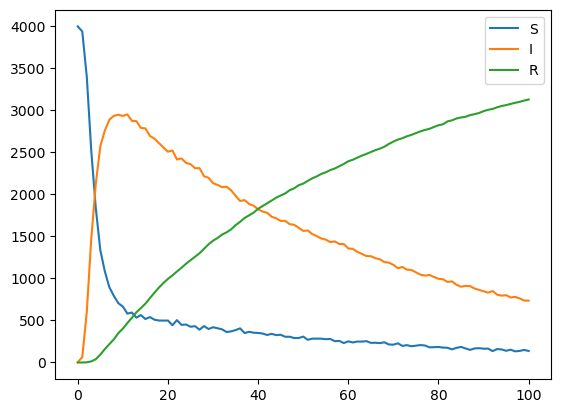

In [8]:
plt.plot(truth_state[...,0].sum(axis=(1,2)),label = "S")
plt.plot(truth_state[...,1].sum(axis=(1,2)),label = "I")
plt.plot(truth_state[...,2].sum(axis=(1,2)),label = "R")
plt.legend()

In [9]:
#Observation
obs_state = np.zeros((assim_time,obs_width,obs_height,3))
error_level = 0.1
obs_std = np.zeros((assim_time,obs_width,obs_height,3))
obs_std[...,1] = error_level* truth_state[1:,...,1]
obs_std[...,2] = error_level* truth_state[1:,...,2]

obs_state[...,1] = truth_state[1:,...,1] +  np.round(ground_truth_seed.normal(loc = 0,scale = obs_std[...,1],size=(assim_time,obs_width, obs_height))).astype(int)
np.maximum(obs_state[...,1], 0, out=obs_state[...,1])
obs_state[...,2] = truth_state[1:,...,2] +  np.round(ground_truth_seed.normal(loc = 0,scale = obs_std[...,2],size=(assim_time,obs_width, obs_height))).astype(int)
np.maximum(obs_state[...,2], 0, out=obs_state[...,2])

obs_state[...,0] = truth_state[1:,...].sum(axis=(3)) - obs_state[...,1] - obs_state[...,2]

obs_state[...,0],obs_state[...,1],obs_state[...,2] = sir_balance(obs_state[...,0],obs_state[...,1],obs_state[...,2])

obs_std[obs_std<0.1] = 0.1

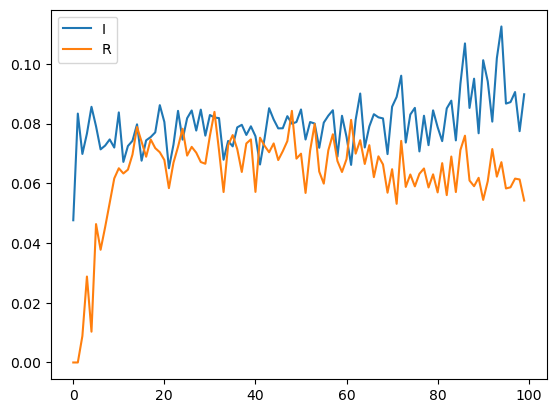

In [10]:
# plt.plot(np.abs(truth_state[1:,...,0]-obs_state[...,0]).sum(axis=(1,2))/(truth_state[1:,...,0]+0).sum(axis=(1,2)),label = "S")
plt.plot(np.abs(truth_state[1:,...,1]-obs_state[...,1]).sum(axis=(1,2))/(truth_state[1:,...,1]+0).sum(axis=(1,2)),label = "I")
plt.plot(np.abs(truth_state[1:,...,2]-obs_state[...,2]).sum(axis=(1,2))/(truth_state[1:,...,2]+1).sum(axis=(1,2)),label = "R")
plt.legend()

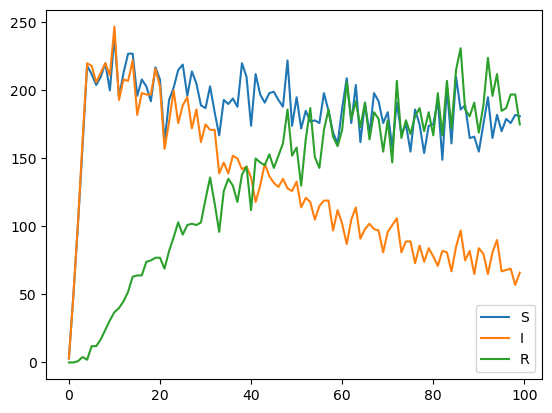

In [11]:
#obs vs truth error
plt.plot(np.abs(obs_state[...,0]-truth_state[1:,...,0]).sum(axis=(1,2)),label = "S")
plt.plot(np.abs(obs_state[...,1]-truth_state[1:,...,1]).sum(axis=(1,2)),label = "I")
plt.plot(np.abs(obs_state[...,2]-truth_state[1:,...,2]).sum(axis=(1,2)),label = "R")
plt.legend()

## Case 1 -- Model Only

In [14]:
ens_noda = np.zeros((assim_time+1,ens_size,obs_width,obs_height,3))

for i in range(ens_size):
    ens_noda[0,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
    ens_noda[0,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
    ens_noda[0,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
for t in range(assim_time):
    # Step
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_noda[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_noda[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_noda[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
        models[f"ens_{i}"].match_sir_statistics(ens_noda[t+1,i,:,:,0], ens_noda[t+1,i,:,:,1], ens_noda[t+1,i,:,:,2])



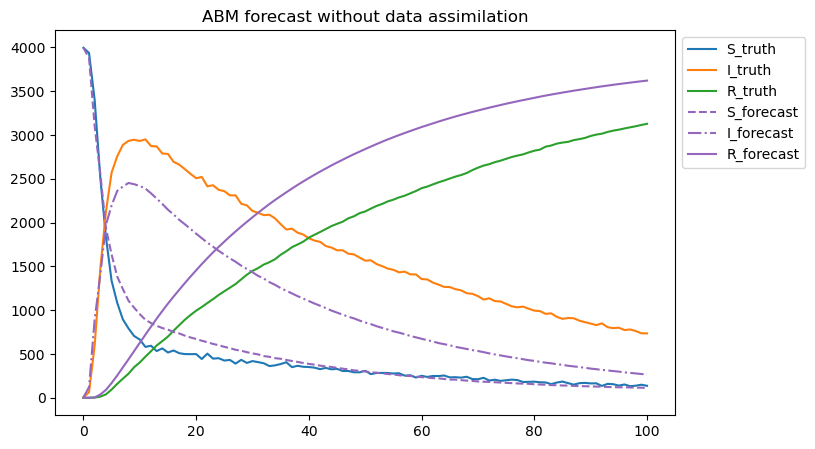

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(truth_state[...,0].sum(axis=(1,2)),label = "S_truth",color='tab:blue', linestyle='-')
plt.plot(truth_state[...,1].sum(axis=(1,2)),label = "I_truth", color='tab:orange', linestyle='-')
plt.plot(truth_state[...,2].sum(axis=(1,2)),label = "R_truth", color='tab:green', linestyle='-')
plt.plot(ens_noda[...,0].mean(axis=1).sum(axis=(1,2)),label = "S_forecast", color='tab:purple', linestyle='--')
plt.plot(ens_noda[...,1].mean(axis=1).sum(axis=(1,2)),label = "I_forecast", color='tab:purple', linestyle='-.')
plt.plot(ens_noda[...,2].mean(axis=1).sum(axis=(1,2)),label = "R_forecast", color='tab:purple', linestyle='-')
plt.title("ABM forecast without data assimilation")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Case 2 -- State estimation via EnSF

In [ ]:
# Create ensemble models
models = {}
initial_outbreak_size_ens=4     

for i in range(ens_size):
    models[f"ens_{i}"] = disease_model.LookupTableDiseaseModel(
        spread_chance_ens[i],
        recovery_chance_ens[i],
        gain_resistance_chance_ens,
        initial_outbreak_size=4,
        **shared_properties
    )
# Lastly, make sure that the model starts with the same agent distribution as the ground truth.
# To do this, we call load_state but only provide the agent (so steps, disease_props and random are *not* copied)
th_agent_state = model_truth_copy.dump_state()['agents']
for i in range(ens_size):
    models[f"ens_{i}"].load_state({'agents': th_agent_state}) 

In [ ]:
#test
ens_state_case2 = np.zeros((assim_time+1,ens_size,obs_width,obs_height,3))
ens_prior_case2 = np.zeros((assim_time+1,ens_size,obs_width,obs_height,3))

for i in range(ens_size):
    ens_state_case2[0,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
    ens_state_case2[0,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
    ens_state_case2[0,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
ens_prior_case2[0] = ens_state_case2[0].copy()

ens_state_case2_sum = ens_state_case2[0].sum(axis=3)
EnSF_Update_state = EnSF(n_dim = obs_width*obs_height*2, ensemble_size = ens_size ,eps_alpha=0.05, device= 'cpu' ,\
                   obs_sigma = obs_std[0,...,1:3].reshape(obs_width*obs_height*2), euler_steps = 1000, scalefact = 1, init_std_x_state = 2,  ISarctan=False)

for t in range(100):   #assim_time
    # Step
    print("now is time" ,  t)
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_state_case2[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_state_case2[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_state_case2[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
        ens_prior_case2[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_prior_case2[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_prior_case2[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])

    if t< 30:
        pre_inf = np.random.normal(loc=0.0, scale=1, size=ens_state_case2[t+1, :, :, :, 1:3].shape)
        ens_state_case2[t+1,:,:,:,1:3] += pre_inf
        xens = EnSF_Update_state.state_update_normalized(x_input= ens_state_case2[t+1,:,:,:,1:3].reshape(ens_size,obs_width*obs_height*2), \
                                                        obs_input= obs_state[t,...,1:3].reshape(obs_width*obs_height*2), sparse_idx = np.arange(obs_width*obs_height*2),arcindex= np.array([], dtype=int))
        xens = xens.numpy().reshape(ens_size,obs_width,obs_height,2)
        xens[xens<0] = 0
        ens_state_case2[t+1,:,:,:,1] = np.round(xens[...,0])
        ens_state_case2[t+1,:,:,:,2] = np.round(xens[...,1])
        ens_state_case2[t+1,:,:,:,0] = (ens_state_case2_sum - ens_state_case2[t+1,:,:,:,1] - ens_state_case2[t+1,:,:,:,2])
        ens_state_case2[t+1,:,:,:,0], ens_state_case2[t+1,:,:,:,1], ens_state_case2[t+1,:,:,:,2] = sir_balance(ens_state_case2[t+1,:,:,:,0], ens_state_case2[t+1,:,:,:,1], ens_state_case2[t+1,:,:,:,2])
        S = ens_state_case2[t+1,:,:,:,0].astype(int)
        I = ens_state_case2[t+1,:,:,:,1].astype(int)
        R = ens_state_case2[t+1,:,:,:,2].astype(int)
        for i in range(ens_size):
            models[f"ens_{i}"].match_sir_statistics(S[i], I[i], R[i])


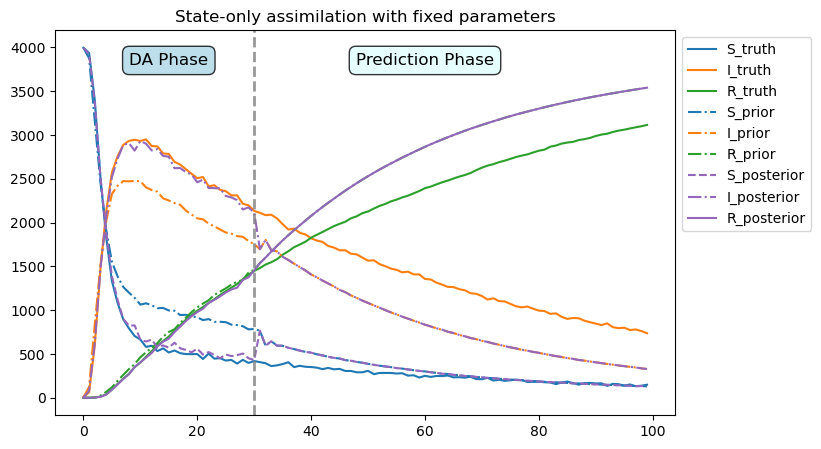

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(truth_state[:100,...,0].sum(axis=(1,2)),label = "S_truth",color='tab:blue', linestyle='-')
plt.plot(truth_state[:100,...,1].sum(axis=(1,2)),label = "I_truth", color='tab:orange', linestyle='-')
plt.plot(truth_state[:100,...,2].sum(axis=(1,2)),label = "R_truth", color='tab:green', linestyle='-')
plt.plot(ens_prior_case2[:100,...,0].mean(axis=1).sum(axis=(1,2)),label = "S_prior", color='tab:blue', linestyle='-.')
plt.plot(ens_prior_case2[:100,...,1].mean(axis=1).sum(axis=(1,2)),label = "I_prior", color='tab:orange', linestyle='-.')
plt.plot(ens_prior_case2[:100,...,2].mean(axis=1).sum(axis=(1,2)),label = "R_prior", color='tab:green', linestyle='-.')
plt.plot(ens_state_case2[:100,...,0].mean(axis=1).sum(axis=(1,2)),label = "S_posterior", color='tab:purple', linestyle='--')
plt.plot(ens_state_case2[:100,...,1].mean(axis=1).sum(axis=(1,2)),label = "I_posterior", color='tab:purple', linestyle='-.')
plt.plot(ens_state_case2[:100,...,2].mean(axis=1).sum(axis=(1,2)),label = "R_posterior", color='tab:purple', linestyle='-')
plt.axvline(x=30, color='tab:gray', linestyle='--', alpha=0.8, linewidth=2)
plt.text(15, 3800, 'DA Phase', ha='center', fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))
plt.text(60, 3800, 'Prediction Phase', ha='center', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightcyan", alpha=0.8))
plt.title("State-only assimilation with fixed parameters")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

## Case 3 -- joint state estimation and parameter estimation via EnSF

In [ ]:
# Create ensemble models
models = {}
initial_outbreak_size_ens=4     

for i in range(ens_size):
    models[f"ens_{i}"] = disease_model.LookupTableDiseaseModel(
        spread_chance_ens[i],
        recovery_chance_ens[i],
        gain_resistance_chance_ens,
        initial_outbreak_size=4,
        **shared_properties
    )

# Lastly, make sure that the model starts with the same agent distribution as the ground truth.
# To do this, we call load_state but only provide the agent (so steps, disease_props and random are *not* copied)
th_agent_state = model_truth_copy.dump_state()['agents']
for i in range(ens_size):
    models[f"ens_{i}"].load_state({'agents': th_agent_state}) 

In [ ]:
ens_state = np.zeros((assim_time+1,ens_size,obs_width,obs_height,3))
ens_parameter = np.zeros((assim_time+1,ens_size,obs_width,obs_height,2))
ens_prior = np.zeros((assim_time+1,ens_size,obs_width,obs_height,3))

for i in range(ens_size):
    ens_state[0,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
    ens_state[0,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
    ens_state[0,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
    ens_parameter[0,i,:,:,0] = models[f"ens_{i}"].disease_props.spread_chance_table
    ens_parameter[0,i,:,:,1] = models[f"ens_{i}"].disease_props.recovery_chance_table
ens_state_sum = ens_state[0].sum(axis=3)
ens_prior[0] = ens_state[0].copy()

EnSF_Update_state = EnSF(n_dim = obs_width*obs_height*2, ensemble_size = ens_size ,eps_alpha=0.05, device= 'cpu' ,\
                   obs_sigma = obs_std[0,...,1:3].reshape(obs_width*obs_height*2), euler_steps = 1000, scalefact = 1, init_std_x_state = 2,  ISarctan=False)

EnSF_Update_para = EnSF(n_dim = obs_width*obs_height*2, ensemble_size = ens_size ,eps_alpha=0.05, device= 'cpu' ,\
                   obs_sigma = 0.1, euler_steps = 1000, scalefact = 1, init_std_x_state = 0.1,  ISarctan=False)

for t in range(30):   #assim_time
    # Step
    print("now is time" ,  t)
    EnSF_Update_para.init_std_x_state = 0.1 - 0.05*i/60
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_state[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_state[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_state[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
        ens_prior[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_prior[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_prior[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
 
    #DA for state variables
    pre_inf = np.random.normal(loc=0.0, scale=1, size=ens_state[t+1, :, :, :, 1:3].shape)
    ens_state[t+1,:,:,:,1:3] += pre_inf
    xens = EnSF_Update_state.state_update_normalized(x_input= ens_state[t+1,:,:,:,1:3].reshape(ens_size,obs_width*obs_height*2), \
                                                     obs_input= obs_state[t,...,1:3].reshape(obs_width*obs_height*2), sparse_idx = np.arange(obs_width*obs_height*2),arcindex= np.array([], dtype=int))
    xens = xens.numpy().reshape(ens_size,obs_width,obs_height,2)
    xens[xens<0] = 0
    ens_state[t+1,:,:,:,1] = np.round(xens[...,0])
    ens_state[t+1,:,:,:,2] = np.round(xens[...,1])
    ens_state[t+1,:,:,:,0] = (ens_state_sum - ens_state[t+1,:,:,:,1] - ens_state[t+1,:,:,:,2])
    ens_state[t+1,:,:,:,0], ens_state[t+1,:,:,:,1], ens_state[t+1,:,:,:,2] = sir_balance(ens_state[t+1,:,:,:,0], ens_state[t+1,:,:,:,1], ens_state[t+1,:,:,:,2])
    S = ens_state[t+1,:,:,:,0].astype(int)
    I = ens_state[t+1,:,:,:,1].astype(int)
    R = ens_state[t+1,:,:,:,2].astype(int)

    for i in range(ens_size):
        models[f"ens_{i}"].match_sir_statistics(S[i], I[i], R[i])

    #DA for parameters
    for i in range(ens_size):
        ens_parameter[t+1,i,:,:,0] = models[f"ens_{i}"].disease_props.spread_chance_table
        ens_parameter[t+1,i,:,:,1] = models[f"ens_{i}"].disease_props.recovery_chance_table

    ens_state_std = np.abs(ens_prior[t+1,:,:,:,0:2]-xens[...]).mean(axis =0)
    likelihoods = (1 / (np.sqrt(2 * np.pi) * ens_state_std)) * np.exp(-0.5 * ((ens_prior[t+1,:,:,:,0:2]- xens[...].mean(axis=0)) / ens_state_std) ** 2) 
    weights = likelihoods / np.sum(likelihoods,axis = 0)
    para_avg = (ens_parameter[t+1] * weights).sum(axis=0)
    para_ens = EnSF_Update_para.parameter_update(parameter_input= ens_parameter[t+1,:,:,:,:].reshape(ens_size,obs_width*obs_height*2), \
                                                    obs_input= para_avg.reshape(obs_width*obs_height*2))
    para_ens = check_paramater(para_ens.numpy().reshape(ens_size,obs_width,obs_height,2))

    for i in range(ens_size):
        ens_parameter[t+1,i,:,:,0] = para_ens[i,:,:,0]
        ens_parameter[t+1,i,:,:,1] = para_ens[i,:,:,1]
        models[f"ens_{i}"].disease_props.spread_chance_table   = ens_parameter[t+1,i,:,:,0]
        models[f"ens_{i}"].disease_props.recovery_chance_table = ens_parameter[t+1,i,:,:,1]

I_avg = np.round(ens_state[t+1,:,:,:,1].mean(axis=0)).astype(int)
R_avg = np.round(ens_state[t+1,:,:,:,2].mean(axis=0)).astype(int)
S_avg = (ens_state_sum[0] - I_avg  - R_avg ).astype(int)
S_avg, I_avg, R_avg =(sir_balance(S_avg, I_avg, R_avg))
for i in range(ens_size):
    models[f"ens_{i}"].disease_props.spread_chance_table   = ens_parameter[t+1,:,:,:,0].mean(axis=0)
    models[f"ens_{i}"].disease_props.recovery_chance_table = ens_parameter[t+1,:,:,:,1].mean(axis=0)

for t in range(30,100):   #assim_time
    # Step
    print("now is time" ,  t)
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_state[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_state[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_state[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])
        ens_prior[t+1,i,:,:,0] = disease_model.measure_local_susceptible(models[f"ens_{i}"])
        ens_prior[t+1,i,:,:,1] = disease_model.measure_local_infected(models[f"ens_{i}"])
        ens_prior[t+1,i,:,:,2] = disease_model.measure_local_resistant(models[f"ens_{i}"])



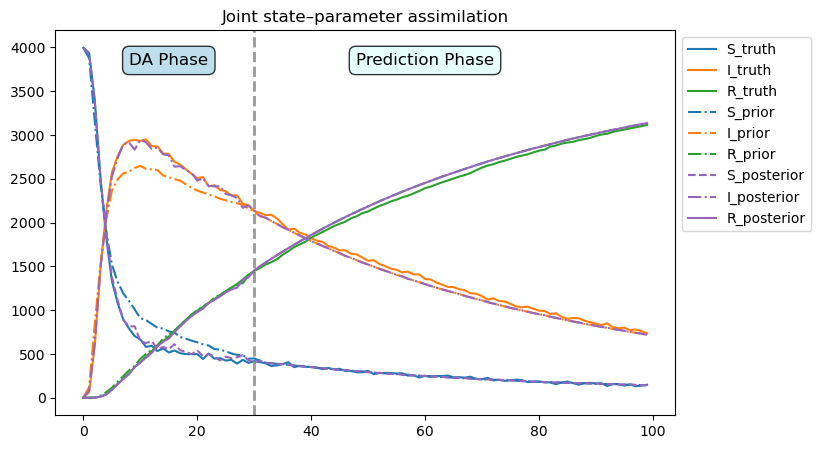

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(truth_state[:100,...,0].sum(axis=(1,2)),label = "S_truth",color='tab:blue', linestyle='-')
plt.plot(truth_state[:100,...,1].sum(axis=(1,2)),label = "I_truth", color='tab:orange', linestyle='-')
plt.plot(truth_state[:100,...,2].sum(axis=(1,2)),label = "R_truth", color='tab:green', linestyle='-')
plt.plot(ens_prior[:100,...,0].mean(axis=1).sum(axis=(1,2)),label = "S_prior", color='tab:blue', linestyle='-.')
plt.plot(ens_prior[:100,...,1].mean(axis=1).sum(axis=(1,2)),label = "I_prior", color='tab:orange', linestyle='-.')
plt.plot(ens_prior[:100,...,2].mean(axis=1).sum(axis=(1,2)),label = "R_prior", color='tab:green', linestyle='-.')
plt.plot(ens_state[:100,...,0].mean(axis=1).sum(axis=(1,2)),label = "S_posterior", color='tab:purple', linestyle='--')
plt.plot(ens_state[:100,...,1].mean(axis=1).sum(axis=(1,2)),label = "I_posterior", color='tab:purple', linestyle='-.')
plt.plot(ens_state[:100,...,2].mean(axis=1).sum(axis=(1,2)),label = "R_posterior", color='tab:purple', linestyle='-')
plt.axvline(x=30, color='grey', linestyle='--', alpha=0.8, linewidth=2)
plt.text(15, 3800, 'DA Phase', ha='center', fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))
plt.text(60, 3800, 'Prediction Phase', ha='center', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightcyan", alpha=0.8))
plt.title("Joint state–parameter assimilation")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))